# Boxplots

In [1]:
import numpy as np
from scipy.io import wavfile
import IPython.display as ipd
from scipy import signal as sig
from scipy.linalg import solve_toeplitz
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

import Funciones as Funciones
from NNMF_GIF import NNMF_GIF
from MetricasRendimiento import MetricasRendimiento

# Carga de la señal

In [2]:
fs_r = 8000
cmap = Funciones.parula_map
color_flujo = 'blue'
color_dflujo = 'red'
color_area = 'orange'
color_darea = 'g'
color_energia = 'magenta'
color_speech = 'black'
legend_loc = 'upper right'

combinacion_archivos = [["Completa hombre","Hombre A", "Hombre Ae", "Hombre I", "Hombre U", "Hombre 82Hz","Hombre 110Hz","Hombre 156Hz","Hombre 220Hz"],
                        ["Completa Mujer","Mujer A", "Mujer Ae", "Mujer I", "Mujer U", "Mujer 175Hz","Mujer 196Hz","Mujer 220Hz","Mujer 294Hz"],
                        ["Completa todas","Completa A","Completa AE", "Completa I","Completa U","Baja frecuencia","Media frecuencia","Alta frecuencia"]]

etiquetas = [["Todas","/a/","/ae/","/i/","/u/","82 Hz","110 Hz","156 Hz","220 Hz"],
             ["Todas","/a/","/ae/","/i/","/u/","175 Hz","194 Hz","220 Hz","294 Hz"],
             ["Todas","/a/","/ae/","/i/","/u/","Baja $f$","Media $f$","Alta $f$"]]

# Definición de parámetros

In [3]:
norma ='fro'
pre_iteraciones = 10
iteraciones     = 250
p_filtro        = 12

# Cálculo de los errores

In [4]:
Errores_1 = []
Errores_2 = []

for i in range(len(combinacion_archivos)):
    for archivo in combinacion_archivos[i]:
        with open("Señales Repositorio II Resampleadas/Listas señales/"+archivo+".txt", "r") as f:
            archivos = [line.strip() for line in f]
            Error1 = []
            Error2 = []
            for caso in archivos:
                señales       = np.loadtxt("Señales Repositorio II Resampleadas/"+caso+".txt", delimiter="\t")
                tiempos_      = señales[:, 0]
                señal_speech_ = señales[:, 1]
                señal_flujo_  = señales[:, 2]
                señal_dflujo_ = señales[:, 3]
                señal_area_   = señales[:, 4]
                señal_darea_  = señales[:, 5]
                to = 750
                tf = 800
                no = int(np.round(to *fs_r/1000)) 
                nf = int(np.round(tf * fs_r/1000))
                tiempos       = tiempos_[no:nf]

                señal_speech  = señal_speech_[no:nf]
                señal_flujo   = señal_flujo_[no:nf]
                señal_dflujo   = señal_dflujo_[no:nf]
                señal_area    = señal_area_[no:nf]
                señal_darea   = señal_darea_[no:nf]
                SP1 = NNMF_GIF(señal_speech,tiempos,fs_r,norma='fro',pre_iteraciones=pre_iteraciones,iteraciones=iteraciones,p_filtro=p_filtro)
                SP2 = NNMF_GIF(señal_speech,tiempos,fs_r,norma='itakura-saito',pre_iteraciones=pre_iteraciones,iteraciones=iteraciones,p_filtro=p_filtro)

                señal_flujo  = señal_flujo[SP1.orden_filtro_tracto-1:len(señal_flujo)-SP1.orden_filtro_tracto-1]
                señal_dflujo = señal_dflujo[SP1.orden_filtro_tracto-1:len(señal_dflujo)-SP1.orden_filtro_tracto-1]

                tiempo_dflujo1,señal_dflujo_1,dflujo1 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_dflujo,SP1.dflujo1)
                tiempo_dflujo2,señal_dflujo_2,dflujo2 = Funciones.Sincronizar2(SP2.tiempos_gve,señal_dflujo,SP2.dflujo1)


                MR1 = MetricasRendimiento(señal_dflujo_1,Funciones.Escalar(dflujo1,señal_dflujo_1),fs_r,tiempo_dflujo1)
                MR2 = MetricasRendimiento(señal_dflujo_2,Funciones.Escalar(dflujo2,señal_dflujo_2),fs_r,tiempo_dflujo2)
                Error1.append(MR1.Error)
                Error2.append(MR2.Error)
            Errores_1.append(Error1)
            Errores_2.append(Error2)

# Gráficas

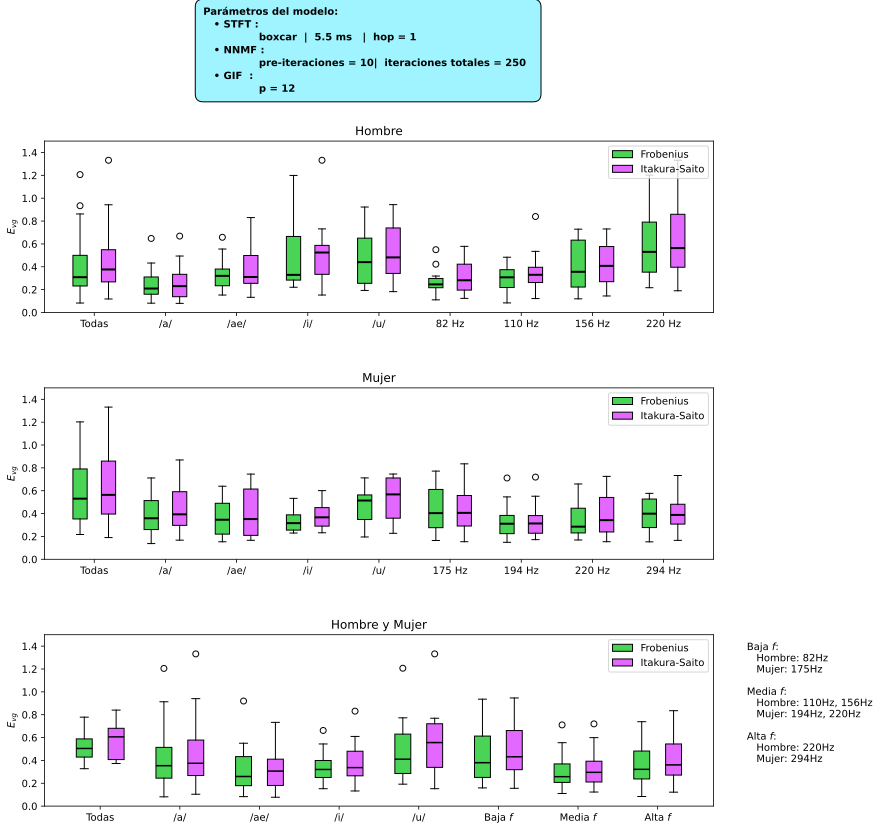

In [24]:
fig,ax = plt.subplots(3,1,figsize=(12,12))
plt.subplots_adjust(top=None, bottom=None, left=None, right=None, hspace=0.44)

color1= (0.29, 0.831, 0.337)
color2 = (0.89, 0.408, 1)

offset = 0.2  # separación horizontal 
for i in range(len(combinacion_archivos[0])):
    ax[0].boxplot(
        Errores_1[i],
        positions=[i - offset],     
        widths=0.2,
        patch_artist=True,
        #showmeans=True,
        #meanline=True,
        #meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 2},
        boxprops={'facecolor': color1, 'color': 'black'},
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'}
    )
    ax[0].boxplot(
        Errores_2[i],
        positions=[i + offset],    
        widths=0.2,
        patch_artist=True,
        #showmeans=True,
        #meanline=True,
        #meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 2},
        boxprops={'facecolor': color2, 'color': 'black'},
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'}
    )
ax[0].set_xticks(range(len(combinacion_archivos[0])))
ax[0].set_xticklabels(etiquetas[0])
ax[0].set_title("Hombre")
ax[0].set_ylabel(r"$E_{vg}$")
ax[0].set_ylim([0,1.5])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color1, edgecolor='black', label="Frobenius"),
    Patch(facecolor=color2, edgecolor='black', label="Itakura-Saito")
]
ax[0].legend(handles=legend_elements, loc='upper right')



for i in range(len(combinacion_archivos[1])):
    ax[1].boxplot(
        Errores_1[len(combinacion_archivos[0])-1+ i],
        positions=[i - offset],     
        widths=0.2,
        patch_artist=True,
        #showmeans=True,
        #meanline=True,
        #meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 2},
        boxprops={'facecolor': color1, 'color': 'black'},
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'}
    )
    ax[1].boxplot(
        Errores_2[len(combinacion_archivos[0])-1+i],
        positions=[i + offset],   
        widths=0.2,
        patch_artist=True,
        #showmeans=True,
        #meanline=True,
        #meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 1.5},
        boxprops={'facecolor': color2, 'color': 'black'},
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'}
    )
ax[1].set_xticks(range(len(combinacion_archivos[1])))
ax[1].set_xticklabels(etiquetas[1])
ax[1].set_title("Mujer")
ax[1].set_ylabel(r"$E_{vg}$")
ax[1].set_ylim([0,1.5])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color1, edgecolor='black', label="Frobenius"),
    Patch(facecolor=color2, edgecolor='black', label="Itakura-Saito")
]
ax[1].legend(handles=legend_elements, loc='upper right')

for i in range(len(combinacion_archivos[2])):
    ax[2].boxplot(
        Errores_1[len(combinacion_archivos[0])+len(combinacion_archivos[1])-1+ i],
        positions=[i - offset],     
        widths=0.2,
        patch_artist=True,
        #showmeans=True,
        #meanline=True,
        #meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 1.5},
        boxprops={'facecolor': color1, 'color': 'black'},
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'}
    )
    ax[2].boxplot(
        Errores_2[len(combinacion_archivos[0])+len(combinacion_archivos[1])-1+i],
        positions=[i + offset],   
        widths=0.2,
        patch_artist=True,
        #showmeans=True,
        #meanline=True,
        #meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 1.5},
        boxprops={'facecolor': color2, 'color': 'black'},
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'}
    )

ax[2].set_xticks(range(len(combinacion_archivos[2])))
ax[2].set_xticklabels(etiquetas[2])
ax[2].set_title("Hombre y Mujer")
ax[2].set_ylabel(r"$E_{vg}$")
ax[2].set_ylim([0,1.5])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color1, edgecolor='black', label="Frobenius"),
    Patch(facecolor=color2, edgecolor='black', label="Itakura-Saito")
]
ax[2].legend(handles=legend_elements, loc='upper right')
ax[-1].text(
    1.05, 0.6,    # posición (x,y) relativa al eje (1.0 está justo al borde derecho)
    f"Baja $f$: \n   Hombre: 82Hz \n   Mujer: 175Hz\n\nMedia $f$: \n   Hombre: 110Hz, 156Hz \n   Mujer: 194Hz, 220Hz \n\nAlta $f$: \n   Hombre: 220Hz \n   Mujer: 294Hz",
    transform=ax[-1].transAxes,  # coordenadas relativas al eje
    fontsize=10,
    va='center', ha='left'
);
# ===============================  Recuadro con los parámetros del modelo ==============================================================================================
fig.text(
0.5, 1.035,  # centrado horizontalmente respecto a la figura
f"Parámetros del modelo:\n"
f"   • STFT : \n                {SP1.ventana}  |  {SP1.duracion_ventana:.1f} ms   |  hop = {SP1.desplazamiento}\n"
f"   • NNMF : \n                pre-iteraciones = {SP1.n_pre_itereraciones}|  iteraciones totales = {SP1.n_iteraciones}  \n"
f"   • GIF  : \n                p = {SP1.orden_filtro_tracto}",
ha='center', va='top',                 # centra el recuadro
multialignment='left',                 # alinea el texto la izquierda
fontsize=10, fontweight='bold',
linespacing=1.4,
bbox=dict(facecolor=(0.624, 0.957, 1), edgecolor='black', boxstyle='round,pad=0.8')
);
fig.savefig("Prueba Repositorio II/Boxplots.pdf",bbox_inches = 'tight');
